--- Starting Production Simulation (10,000 Paths) ---
1. Running Baseline...
2. Running Brown Shock (Transition Risk)...

--- Final Stress Test Results (Ordered by Risk Underestimation) ---
        ES_Baseline   ES_Shock  Risk_Gap_Dollar  Risk_Gap_Percent
Ticker                                                           
BAC       26.893113  40.048312        13.155198         48.916606
C         28.955610  42.986493        14.030883         48.456526
JPM       24.554353  36.367529        11.813176         48.110313
GS        25.557622  37.022821        11.465199         44.860196
MS        27.394813  39.234609        11.839797         43.219120
BCS       31.579152  42.866594        11.287442         35.743334
DB        32.968446  43.463839        10.495393         31.834659


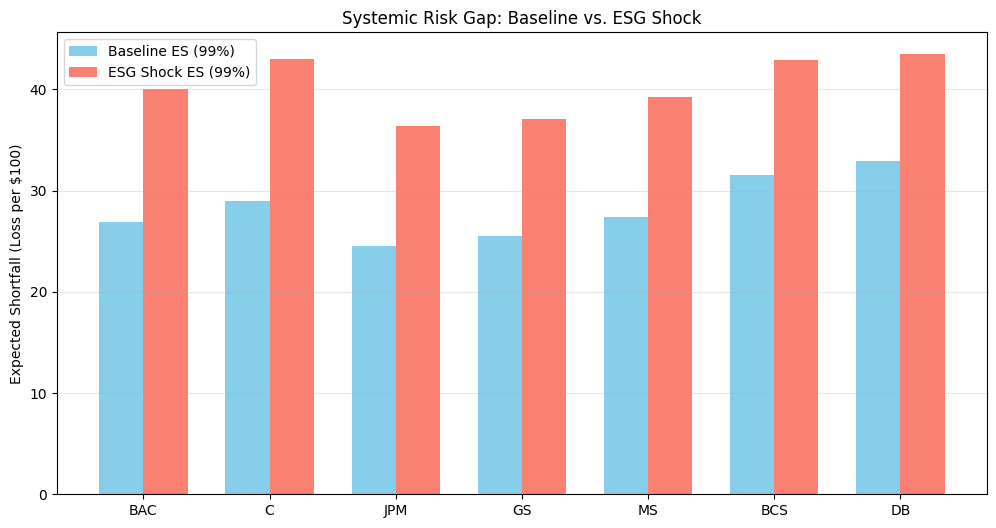

[SUCCESS] Final Table saved to ..\..\outputs\tables\final_risk_metrics.csv
[SUCCESS] Final Plot saved to ..\..\outputs\figures\systemic_risk_gap.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add src to path if needed (or just run inline for simplicity in this phase)
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# 1. Load Processed Data
data_path = os.path.join("..", "..", "data", "processed")
returns_df = pd.read_csv(os.path.join(data_path, "market_returns.csv"), index_col=0, parse_dates=True)
esg_df = pd.read_csv(os.path.join(data_path, "esg_sensitivity.csv"), index_col=0)

# Filter Clearing Members
cm_tickers = ['JPM', 'GS', 'MS', 'BAC', 'C', 'DB', 'BCS']
cm_returns = returns_df[cm_tickers]

# 2. Re-Define Simulation Engine (copying class for standalone execution)
# In a production app, this would be imported from src.models
class CCPRiskEngine:
    def __init__(self, returns_data, esg_betas, num_sims=10000, horizon=30):
        self.returns = returns_data
        self.esg_betas = esg_betas
        self.num_sims = num_sims
        self.horizon = horizon
        self.tickers = returns_data.columns.tolist()
        self.num_assets = len(self.tickers)
        self.corr_matrix = returns_data.corr()
        self.L = np.linalg.cholesky(self.corr_matrix)
        
    def generate_scenarios(self, shock_type=None, shock_magnitude=-0.20):
        dt = 1
        paths = np.zeros((self.horizon, self.num_sims, self.num_assets))
        current_prices = np.ones((self.num_sims, self.num_assets)) * 100
        
        for t in range(self.horizon):
            Z = np.random.normal(0, 1, size=(self.num_sims, self.num_assets))
            correlated_shocks = np.dot(Z, self.L.T)
            
            esg_impact = np.zeros((self.num_sims, self.num_assets))
            if t == 0 and shock_type is not None:
                if shock_type == 'Brown':
                    betas = self.esg_betas.loc[self.tickers, 'Brown_Beta (XLE)'].values
                    impact_vector = shock_magnitude * betas
                elif shock_type == 'Green':
                    betas = self.esg_betas.loc[self.tickers, 'Green_Beta (ICLN)'].values
                    impact_vector = shock_magnitude * betas
                esg_impact = np.tile(impact_vector, (self.num_sims, 1))

            daily_vol = self.returns.std().values 
            simulated_returns = (daily_vol * correlated_shocks) + esg_impact
            current_prices = current_prices * np.exp(simulated_returns)
            paths[t] = current_prices
        return paths

# 3. Execution: The Large-Scale Run
print("--- Starting Production Simulation (10,000 Paths) ---")
engine = CCPRiskEngine(cm_returns, esg_df, num_sims=10000, horizon=30)

# Scenario A: Baseline (Normal Market)
print("1. Running Baseline...")
paths_base = engine.generate_scenarios(shock_type=None)

# Scenario B: Brown Asset Crash (Oil -30%)
print("2. Running Brown Shock (Transition Risk)...")
paths_shock = engine.generate_scenarios(shock_type='Brown', shock_magnitude=-0.30)

# 4. Result Aggregation
results = []
for i, ticker in enumerate(cm_tickers):
    # Extract final prices
    final_base = paths_base[-1, :, i]
    final_shock = paths_shock[-1, :, i]
    
    # Calculate Risk Metrics (VaR and ES at 99%)
    # Loss = 100 - Price
    loss_base = 100 - final_base
    loss_shock = 100 - final_shock
    
    var_99_base = np.percentile(loss_base, 99)
    es_99_base = loss_base[loss_base > var_99_base].mean()
    
    var_99_shock = np.percentile(loss_shock, 99)
    es_99_shock = loss_shock[loss_shock > var_99_shock].mean()
    
    results.append({
        'Ticker': ticker,
        'ES_Baseline': es_99_base,
        'ES_Shock': es_99_shock,
        'Risk_Gap_Dollar': es_99_shock - es_99_base,
        'Risk_Gap_Percent': ((es_99_shock / es_99_base) - 1) * 100
    })

results_df = pd.DataFrame(results).set_index('Ticker').sort_values('Risk_Gap_Percent', ascending=False)

# 5. Save Final Table
output_table_path = os.path.join("..", "..", "outputs", "tables", "final_risk_metrics.csv")
os.makedirs(os.path.dirname(output_table_path), exist_ok=True)
results_df.to_csv(output_table_path)

print("\n--- Final Stress Test Results (Ordered by Risk Underestimation) ---")
print(results_df)

# 6. Generate Final Thesis Plot (Systemic Gap)
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['ES_Baseline'], width, label='Baseline ES (99%)', color='skyblue')
plt.bar(x + width/2, results_df['ES_Shock'], width, label='ESG Shock ES (99%)', color='salmon')

plt.ylabel('Expected Shortfall (Loss per $100)')
plt.title('Systemic Risk Gap: Baseline vs. ESG Shock')
plt.xticks(x, results_df.index)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# Save Figure
output_fig_path = os.path.join("..", "..", "outputs", "figures", "systemic_risk_gap.png")
plt.savefig(output_fig_path, dpi=300)
plt.show()

print(f"[SUCCESS] Final Table saved to {output_table_path}")
print(f"[SUCCESS] Final Plot saved to {output_fig_path}")